<a href="https://colab.research.google.com/github/CharlesSnt/PFE/blob/main/MLP_solution_Marie's_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch

# MLP for forward problem

In [ ]:
import numpy as np
import scipy.io
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.nn.utils import parameters_to_vector

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Initialization
# -----------------------------
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


# -----------------------------
# Model Class - MLP (remplace le CNN)
# -----------------------------
class PhysicsInformedMLP(nn.Module):
    """
    MLP pour prédire directement u, v, p
    Architecture: [3] -> [20, 20, 20, 20, 20, 20, 20, 20] -> [3]
    """
    def __init__(self, layers=[3, 20, 20, 20, 20, 20, 20, 20, 20, 3]):
        super().__init__()

        self.layers_sizes = layers
        self.num_layers = len(layers) - 1

        # Construction du MLP
        self.network = nn.ModuleList()
        for i in range(self.num_layers):
            self.network.append(nn.Linear(layers[i], layers[i+1]))

        self.apply(init_weights)

    def forward(self, xyt):
        """
        Args:
            xyt: tensor de shape (N, 3) avec [x, y, t]

        Returns:
            u, v, p: tensors de shape (N, 1) chacun
        """
        # Si xyt a des dimensions supplémentaires (comme dans ton code avec unsqueeze)
        # on les aplatit d'abord
        if xyt.dim() > 2:
            original_shape = xyt.shape
            xyt = xyt.view(-1, 3)
            needs_reshape = True
        else:
            needs_reshape = False

        h = xyt

        # Propagation à travers les couches cachées avec tanh
        for i in range(self.num_layers - 1):
            h = torch.tanh(self.network[i](h))

        # Dernière couche (linéaire)
        out = self.network[-1](h)

        # Séparer u, v, p
        u = out[:, 0:1]
        v = out[:, 1:2]
        p = out[:, 2:3]

        # Remettre la forme originale si nécessaire
        if needs_reshape:
            u = u.view(original_shape[0], 1, original_shape[2], original_shape[3])
            v = v.view(original_shape[0], 1, original_shape[2], original_shape[3])
            p = p.view(original_shape[0], 1, original_shape[2], original_shape[3])

        return u, v, p


# -----------------------------
# Physics (Navier-Stokes) - CORRIGÉ
# -----------------------------
def navier_stokes_residual(model, xyt, nu=0.01):
    """
    Calcule les résidus de Navier-Stokes
    CORRECTION: Ajoute l'équation de continuité pour l'incompressibilité
    """
    # Aplatir si nécessaire
    if xyt.dim() > 2:
        batch_size = xyt.shape[0]
        xyt = xyt.view(batch_size, 3)

    xyt.requires_grad_(True)

    # Prédiction du modèle
    u, v, p = model(xyt)

    # Aplatir les sorties si elles ont des dimensions supplémentaires
    if u.dim() > 2:
        u = u.view(-1, 1)
        v = v.view(-1, 1)
        p = p.view(-1, 1)

    # Dérivées de u
    u_g = autograd.grad(u, xyt, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x, u_y, u_t = u_g[:, 0:1], u_g[:, 1:2], u_g[:, 2:3]

    # Dérivées de v
    v_g = autograd.grad(v, xyt, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_x, v_y, v_t = v_g[:, 0:1], v_g[:, 1:2], v_g[:, 2:3]

    # Dérivées de p
    p_g = autograd.grad(p, xyt, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_g[:, 0:1], p_g[:, 1:2]

    # Dérivées secondes de u
    u_xx = autograd.grad(
        u_x, xyt, grad_outputs=torch.ones_like(u_x), create_graph=True
    )[0][:, 0:1]
    u_yy = autograd.grad(
        u_y, xyt, grad_outputs=torch.ones_like(u_y), create_graph=True
    )[0][:, 1:2]

    # Dérivées secondes de v
    v_xx = autograd.grad(
        v_x, xyt, grad_outputs=torch.ones_like(v_x), create_graph=True
    )[0][:, 0:1]
    v_yy = autograd.grad(
        v_y, xyt, grad_outputs=torch.ones_like(v_y), create_graph=True
    )[0][:, 1:2]

    # Résidus de Navier-Stokes

    f_u = u_t + u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
    f_v = v_t + u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)

    # CORRECTION: Équation de continuité (incompressibilité)

    f_continuity = u_x + v_y

    return f_u, f_v, f_continuity, u, v, p


def pinn_loss(model, xyt_data, u_true, v_true, xyt_colloc, nu=0.01):

    # 1. Loss données : sur tes 50 points supervisés
    _, _, _, u_pred, v_pred, _ = navier_stokes_residual(model, xyt_data, nu)
    mse_data = ((u_pred - u_true)**2).mean() + ((v_pred - v_true)**2).mean()

    # 2. Loss PDE : sur les points de collocation rééchantillonnés
    f_u, f_v, f_cont, _, _, _ = navier_stokes_residual(model, xyt_colloc, nu)
    mse_pde = (f_u**2).mean() + (f_v**2).mean() + (f_cont**2).mean()

    return mse_data + mse_pde



# -----------------------------
# Generic Training Function
# -----------------------------
def run_training_session(mode_name, xyt, u_true, v_true, xyt_colloc, steps=2000, use_lbfgs=False):
    """
    Lance un entraînement complet selon le mode spécifié.
    Modes: 'adam', 'sgd'
    """
    print(f"\n=== Start to train : {mode_name} (LBFGS={use_lbfgs}) ===")

    # Utiliser le MLP
    layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
    model = PhysicsInformedMLP(layers=layers).to(device)

    if "sgd" in mode_name.lower():
        optimizer = optim.SGD(model.parameters(), lr=1e-2)
    else:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

    weight_history = []

    # --- Principal loop (Adam / SGD) ---
    for it in range(steps):
        optimizer.zero_grad()
        loss = pinn_loss(model, xyt, u_true, v_true, xyt_colloc)
        loss.backward()
        optimizer.step()

        if it % 50 == 0:
            current_w = parameters_to_vector(model.parameters()).detach().cpu()
            weight_history.append(current_w)
            if it % 500 == 0:
                print(f"Iter {it}, Loss: {loss.item():.3e}")

    weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())

    # --- Phase LBFGS (Optionnal) ---
    if use_lbfgs:
        print("Début LBFGS...")
        optimizer_lbfgs = optim.LBFGS(
            model.parameters(),
            max_iter=500,
            tolerance_grad=1e-9,
            tolerance_change=1e-9,
            history_size=50,
            line_search_fn="strong_wolfe",
        )

        def closure():
            optimizer_lbfgs.zero_grad()
            loss = pinn_loss(model, xyt, u_true, v_true, xyt_colloc)
            loss.backward()
            return loss

        optimizer_lbfgs.step(closure)

        weight_history.append(parameters_to_vector(model.parameters()).detach().cpu())

    # Save the loss functions
    suffix = "_lbfgs" if use_lbfgs else ""
    filename_base = f"navier_{mode_name}{suffix}"

    torch.save(model.state_dict(), f"{filename_base}_model.pth")
    torch.save(torch.stack(weight_history), f"{filename_base}_traj.pt")
    print(f"Sauvegardé : {filename_base}_model.pth et .pt")

In [ ]:

# -----------------------------
# MAIN
# -----------------------------
if __name__ == "__main__":
    # Load Data
    data = scipy.io.loadmat("/content/cylinder_nektar_wake.mat")
    U_star = data["U_star"]
    t_star = data["t"]
    X_star = data["X_star"]

    N = X_star.shape[0]
    T = t_star.shape[0]

    XX = np.tile(X_star[:, 0:1], (1, T))
    YY = np.tile(X_star[:, 1:2], (1, T))
    TT = np.tile(t_star, (1, N)).T
    UU = U_star[:, 0, :]
    VV = U_star[:, 1, :]

    x = XX.flatten()[:, None]
    y = YY.flatten()[:, None]
    t = TT.flatten()[:, None]
    u = UU.flatten()[:, None]
    v = VV.flatten()[:, None]

    # Training Data Selection
    N_train = 200
    idx = np.random.choice(N * T, N_train, replace=False)

    x_train = torch.tensor(x[idx, :], dtype=torch.float32)
    y_train = torch.tensor(y[idx, :], dtype=torch.float32)
    t_train = torch.tensor(t[idx, :], dtype=torch.float32)
    u_train = torch.tensor(u[idx, :], dtype=torch.float32)
    v_train = torch.tensor(v[idx, :], dtype=torch.float32)

    # Pour le MLP, on n'a pas besoin des unsqueeze supplémentaires
    xyt_train = torch.cat([x_train, y_train, t_train], dim=1)
    xyt_train.requires_grad_(True)

    xyt_train = xyt_train.to(device)
    u_train = u_train.to(device)
    v_train = v_train.to(device)


    # Random colocations points
    N_colloc = 2000
    idx_colloc = np.random.choice(N * T, N_colloc, replace=False) # Use a different index variable for clarity
    x_colloc = torch.tensor(x[idx_colloc, :], dtype=torch.float32)
    y_colloc = torch.tensor(y[idx_colloc, :], dtype=torch.float32)
    t_colloc = torch.tensor(t[idx_colloc, :], dtype=torch.float32)

    x_colloc.requires_grad_(True)
    y_colloc.requires_grad_(True)
    t_colloc.requires_grad_(True)

    # Stack inputs for MLP: [batch, features]. Removed unsqueeze for consistency with xyt_train.
    xyt_colloc = torch.cat([x_colloc, y_colloc, t_colloc], dim=1)
    xyt_colloc.requires_grad_(True)
    xyt_colloc = xyt_colloc.to(device) # <--- FIX: Move xyt_colloc to the device

    # --- Different trainings ---

    # 1. Adam + LBFGS (Original one)
    run_training_session(
        "adam", xyt_train, u_train, v_train, xyt_colloc, steps=200000, use_lbfgs=True
    )



=== Start to train : adam (LBFGS=True) ===
Iter 0, Loss: 8.620e-01
Iter 500, Loss: 8.544e-02
Iter 1000, Loss: 7.378e-02
Iter 1500, Loss: 4.701e-02
Iter 2000, Loss: 3.705e-02
Iter 2500, Loss: 3.003e-02
Iter 3000, Loss: 2.499e-02
Iter 3500, Loss: 2.111e-02
Iter 4000, Loss: 1.835e-02
Iter 4500, Loss: 1.721e-02
Iter 5000, Loss: 1.468e-02
Iter 5500, Loss: 1.309e-02
Iter 6000, Loss: 1.181e-02
Iter 6500, Loss: 1.094e-02
Iter 7000, Loss: 1.031e-02
Iter 7500, Loss: 9.645e-03
Iter 8000, Loss: 9.267e-03
Iter 8500, Loss: 8.300e-03
Iter 9000, Loss: 8.621e-03
Iter 9500, Loss: 7.521e-03
Iter 10000, Loss: 7.311e-03
Iter 10500, Loss: 7.132e-03
Iter 11000, Loss: 6.297e-03
Iter 11500, Loss: 5.909e-03
Iter 12000, Loss: 5.866e-03
Iter 12500, Loss: 5.529e-03
Iter 13000, Loss: 5.240e-03
Iter 13500, Loss: 8.540e-03
Iter 14000, Loss: 5.060e-03
Iter 14500, Loss: 4.750e-03
Iter 15000, Loss: 4.383e-03
Iter 15500, Loss: 4.379e-03
Iter 16000, Loss: 3.999e-03
Iter 16500, Loss: 3.839e-03
Iter 17000, Loss: 3.927e-03


# Plotting

Modèle chargé : navier_adam_lbfgs_model.pth

Erreurs relatives (snapshot t=19.90s) :
  u : 1.335e-01
  v : 4.060e-01
  p : 3.624e+00


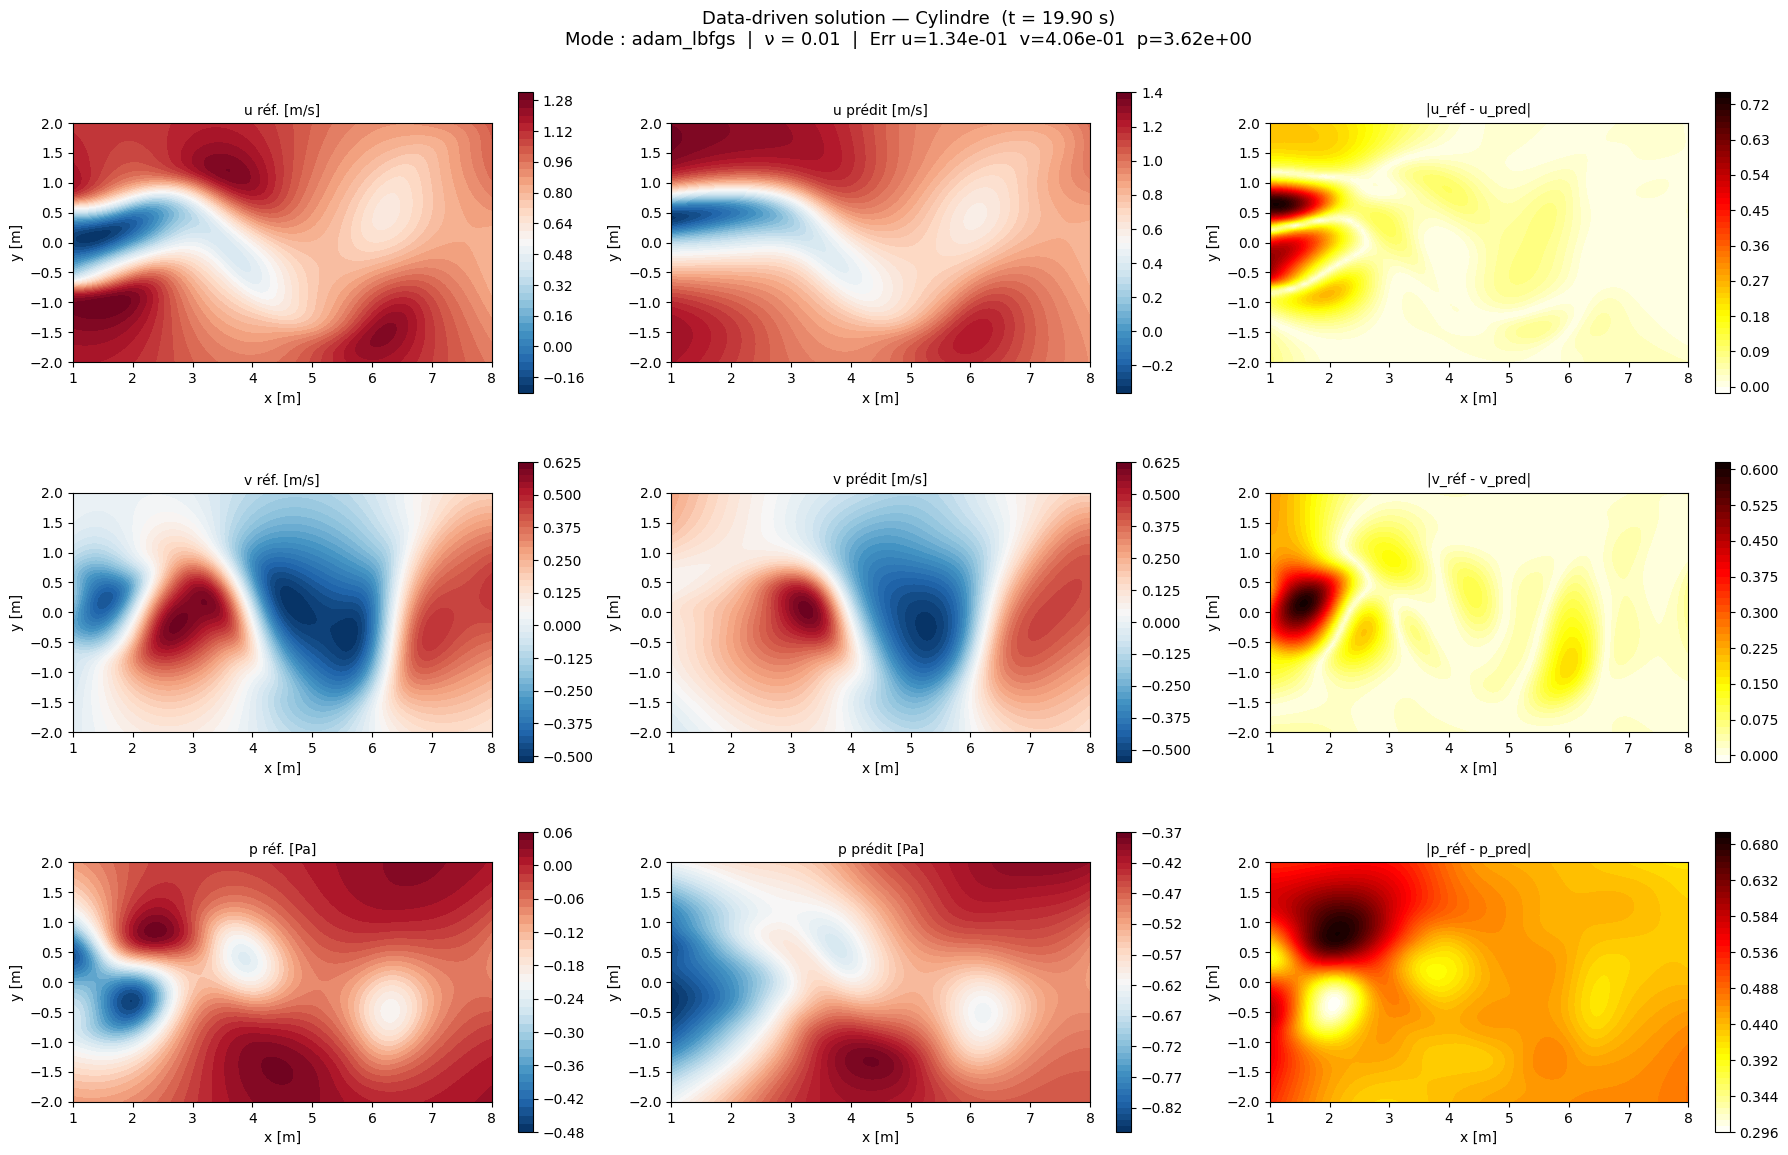

Figure sauvegardée : /content/uvp_adam_lbfgs.png


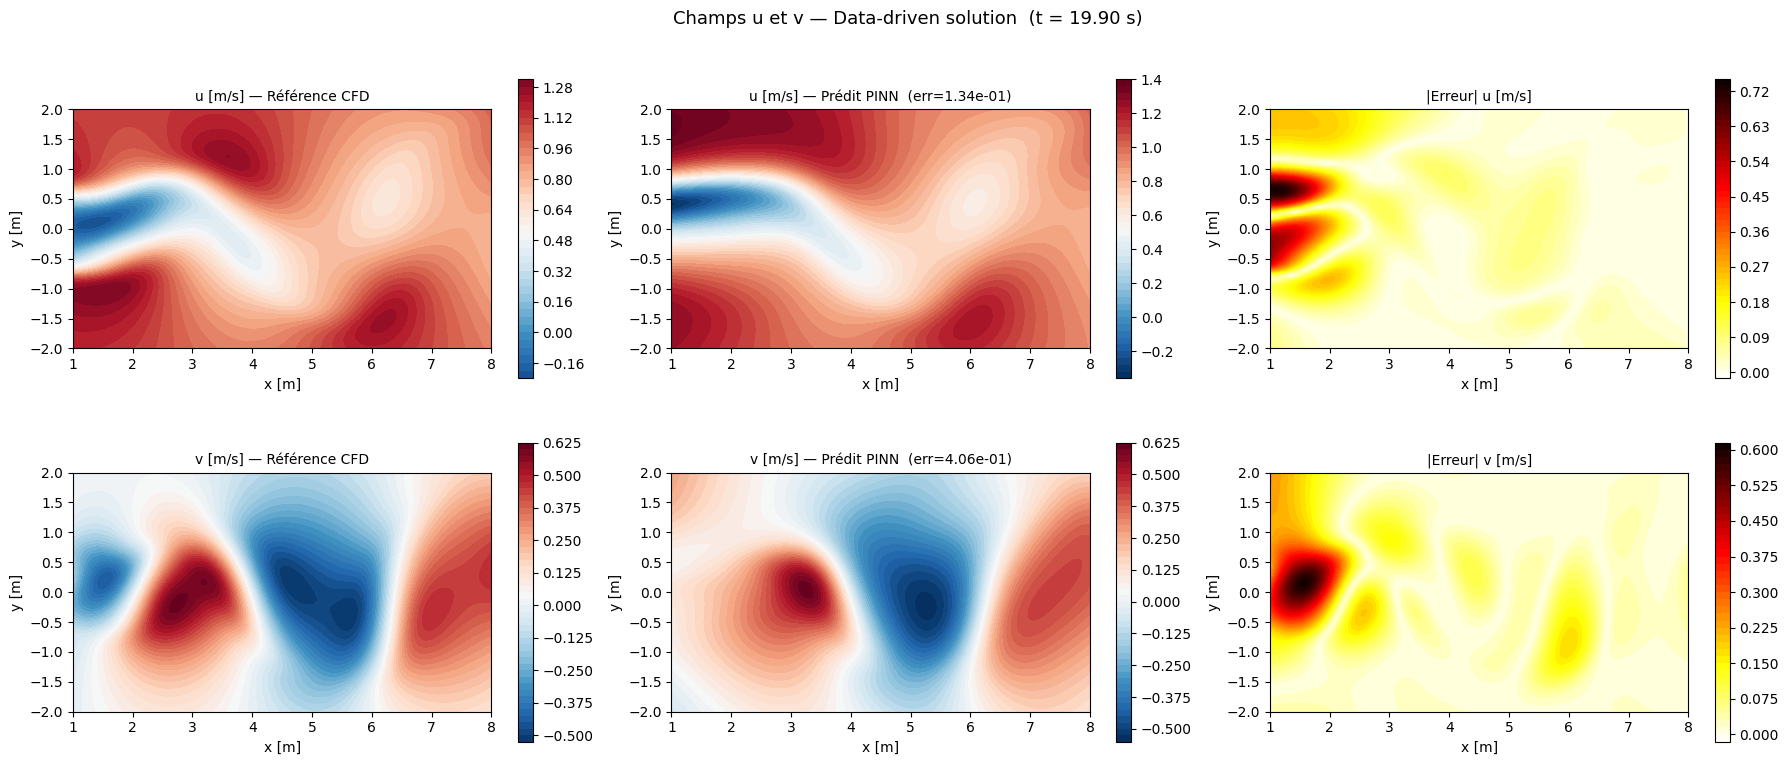

Figure sauvegardée : /content/uv_seulement_adam_lbfgs.png


In [ ]:
# =============================================================================
# VISUALISATION u et v — Data-driven solution (cylindre)
# À exécuter après run_training_session
# =============================================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.io

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# 1. CHARGEMENT DU MODÈLE SAUVEGARDÉ
# =============================================================================
# Adapter le nom selon le mode utilisé (adam, sgd, adam_lbfgs, etc.)
MODE = "adam_lbfgs"

layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
model  = PhysicsInformedMLP(layers=layers).to(device)
model.load_state_dict(torch.load(f"navier_{MODE}_model.pth", map_location=device))
model.eval()
print(f"Modèle chargé : navier_{MODE}_model.pth")

# =============================================================================
# 2. CHARGEMENT DES DONNÉES POUR LA COMPARAISON
# =============================================================================
data   = scipy.io.loadmat("/content/cylinder_nektar_wake.mat")
U_star = data["U_star"]   # (N, 2, T)
P_star = data["p_star"]   # (N, T)
t_star = data["t"]        # (T, 1)
X_star = data["X_star"]   # (N, 2)

N = X_star.shape[0]
T = t_star.shape[0]

XX = np.tile(X_star[:, 0:1], (1, T))   # (N, T)
YY = np.tile(X_star[:, 1:2], (1, T))
TT = np.tile(t_star, (1, N)).T          # (N, T)
UU = U_star[:, 0, :]                    # (N, T)
VV = U_star[:, 1, :]

# On prend un snapshot (instant fixé) pour la visualisation
SNAP = T-1 # ← changer l'instant voulu (0 à T-1)

x_snap = X_star[:, 0]           # (N,)
y_snap = X_star[:, 1]           # (N,)
t_snap = np.full(N, t_star[SNAP, 0])
u_true = U_star[:, 0, SNAP]     # (N,)
v_true = U_star[:, 1, SNAP]     # (N,)
p_true = P_star[:, SNAP]        # (N,)

# =============================================================================
# 3. PRÉDICTION DU MODÈLE
# =============================================================================
xyt_snap = torch.tensor(
    np.stack([x_snap, y_snap, t_snap], axis=1),
    dtype=torch.float32
).to(device)

with torch.no_grad():
    u_pred, v_pred, p_pred = model(xyt_snap)

u_pred = u_pred.cpu().numpy().flatten()
v_pred = v_pred.cpu().numpy().flatten()
p_pred = p_pred.cpu().numpy().flatten()

# Erreurs
err_u = np.linalg.norm(u_true - u_pred) / np.linalg.norm(u_true)
err_v = np.linalg.norm(v_true - v_pred) / np.linalg.norm(v_true)
err_p = np.linalg.norm(p_true - p_pred) / np.linalg.norm(p_true)
print(f"\nErreurs relatives (snapshot t={t_star[SNAP,0]:.2f}s) :")
print(f"  u : {err_u:.3e}")
print(f"  v : {err_v:.3e}")
print(f"  p : {err_p:.3e}")

# =============================================================================
# 4. INTERPOLATION SUR GRILLE RÉGULIÈRE POUR L'AFFICHAGE
# =============================================================================
from scipy.interpolate import griddata

lb = X_star.min(0)
ub = X_star.max(0)
n_grid = 200

x_grid = np.linspace(lb[0], ub[0], n_grid)
y_grid = np.linspace(lb[1], ub[1], n_grid)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

def interp(values):
    return griddata(X_star, values, (X_grid, Y_grid), method='cubic')

U_true_grid  = interp(u_true)
V_true_grid  = interp(v_true)
P_true_grid  = interp(p_true)
U_pred_grid  = interp(u_pred)
V_pred_grid  = interp(v_pred)
P_pred_grid  = interp(p_pred)

U_err_grid   = interp(np.abs(u_true - u_pred))
V_err_grid   = interp(np.abs(v_true - v_pred))
P_err_grid   = interp(np.abs(p_true - p_pred))

# =============================================================================
# 5. FIGURE — u et v (référence / prédit / erreur)
# =============================================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle(f'Data-driven solution — Cylindre  (t = {t_star[SNAP,0]:.2f} s)\n'
             f'Mode : {MODE}  |  ν = 0.01  |  '
             f'Err u={err_u:.2e}  v={err_v:.2e}  p={err_p:.2e}',
             fontsize=13)

configs = [
    # (données,        titre,              cmap,       ligne)
    (U_true_grid,  'u réf. [m/s]',       'RdBu_r',   0),
    (V_true_grid,  'v réf. [m/s]',       'RdBu_r',   1),
    (P_true_grid,  'p réf. [Pa]',        'RdBu_r',   2),
    (U_pred_grid,  'u prédit [m/s]',     'RdBu_r',   0),
    (V_pred_grid,  'v prédit [m/s]',     'RdBu_r',   1),
    (P_pred_grid,  'p prédit [Pa]',      'RdBu_r',   2),
    (U_err_grid,   '|u_réf - u_pred|',   'hot_r',    0),
    (V_err_grid,   '|v_réf - v_pred|',   'hot_r',    1),
    (P_err_grid,   '|p_réf - p_pred|',   'hot_r',    2),
]

col_labels = ['Référence CFD', 'Prédit PINN', 'Erreur absolue']

for col_idx, col_label in enumerate(col_labels):
    axes[0, col_idx].set_title(col_label, fontsize=12, fontweight='bold', pad=10)

for i, (field, title, cmap, row) in enumerate(configs):
    col = i // 3
    ax  = axes[row, col]
    cf  = ax.contourf(X_grid, Y_grid, field, levels=50, cmap=cmap)
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'/content/uvp_{MODE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : /content/uvp_{MODE}.png")

# =============================================================================
# 6. FIGURE SIMPLIFIÉE — u et v seulement (plus lisible)
# =============================================================================
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 8))
fig2.suptitle(f'Champs u et v — Data-driven solution  (t = {t_star[SNAP,0]:.2f} s)',
              fontsize=13)

row_data = [
    (U_true_grid, U_pred_grid, U_err_grid, 'u [m/s]', err_u),
    (V_true_grid, V_pred_grid, V_err_grid, 'v [m/s]', err_v),
]

for row, (true_g, pred_g, err_g, label, err) in enumerate(row_data):
    vmin = min(np.nanmin(true_g), np.nanmin(pred_g))
    vmax = max(np.nanmax(true_g), np.nanmax(pred_g))

    for col, (field, subtitle) in enumerate([
            (true_g, f'{label} — Référence CFD'),
            (pred_g, f'{label} — Prédit PINN  (err={err:.2e})'),
            (err_g,  f'|Erreur| {label}')]):
        ax = axes2[row, col]
        cmap = 'RdBu_r' if col < 2 else 'hot_r'
        kw   = dict(vmin=vmin, vmax=vmax) if col < 2 else {}
        cf   = ax.contourf(X_grid, Y_grid, field, levels=50, cmap=cmap, **kw)
        plt.colorbar(cf, ax=ax, shrink=0.8)
        ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
        ax.set_title(subtitle, fontsize=10)
        ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'/content/uv_seulement_{MODE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : /content/uv_seulement_{MODE}.png")